
# 🏙️ Problem 3: Predicting Housing Prices in New York City

In this project, you will use the NYC Property Sales dataset to build a deep learning regression model that predicts property sale prices.



## 📦 Step 1: Import Required Libraries


In [2]:

# ====================================================
# Step 1: Import Required Libraries
# ====================================================

import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)



## 📂 Step 2: Load the NYC Property Sales Dataset


In [4]:

# ====================================================
# Step 2: Load Dataset
# ====================================================

# Load dataset
data = pd.read_csv("nyc-rolling-sales.csv")

print("Dataset Shape:")
print(data.shape)

print("\nFirst 5 Rows:")
data.head()


Dataset Shape:
(84548, 22)

First 5 Rows:


,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00



## 🧹 Step 3: Data Cleaning and Feature Selection


In [8]:
# ====================================================
# Step 3: Data Cleaning and Feature Selection
# ====================================================

# Remove extra spaces from column names
data.columns = data.columns.str.strip()

# Print column names so we can verify them
print("Dataset Columns:")
print(data.columns.tolist())

# Keep selected features
data = data[[
    "BOROUGH",
    "GROSS_SQUARE_FEET",
    "YEAR_BUILT",
    "SALE_PRICE"
]]

# Replace missing placeholders with NaN
data = data.replace("-", np.nan)

# Remove missing values
data = data.dropna()

# Convert columns to numeric
data["GROSS_SQUARE_FEET"] = pd.to_numeric(
    data["GROSS_SQUARE_FEET"],
    errors="coerce"
)

data["YEAR_BUILT"] = pd.to_numeric(
    data["YEAR_BUILT"],
    errors="coerce"
)

data["SALE_PRICE"] = pd.to_numeric(
    data["SALE_PRICE"],
    errors="coerce"
)

# Remove rows with invalid values
data = data.dropna()

# Remove zero or negative prices
data = data[data["SALE_PRICE"] > 0]

# Remove zero square footage
data = data[data["GROSS_SQUARE_FEET"] > 0]

print("\nCleaned Dataset Shape:")
print(data.shape)

print("\nFirst 5 Cleaned Rows:")
data.head()

Dataset Columns:
['BOROUGH', 'GROSS_SQUARE_FEET', 'YEAR_BUILT', 'SALE_PRICE']

Cleaned Dataset Shape:
(29334, 4)

First 5 Cleaned Rows:


,BOROUGH,GROSS_SQUARE_FEET,YEAR_BUILT,SALE_PRICE
0,1,6440.0,1900,6625000.0
3,1,6794.0,1913,3936272.0
4,1,4615.0,1900,8000000.0
6,1,4226.0,1920,3192840.0
9,1,18523.0,1920,16232000.0



## 🔄 Step 4: One-Hot Encoding and Feature Preparation


In [9]:

# ====================================================
# Step 4: One-Hot Encoding
# ====================================================

# One-hot encode BOROUGH
data_encoded = pd.get_dummies(
    data,
    columns=["BOROUGH"],
    prefix="BOROUGH",
    dtype=int
)

# Separate features and target
X = data_encoded.drop("SALE_PRICE", axis=1).values
y = data_encoded["SALE_PRICE"].values.reshape(-1, 1)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (29334, 7)
Target Shape: (29334, 1)



## 📏 Step 5: Normalize Features and Target


In [10]:

# ====================================================
# Step 5: Feature Scaling
# ====================================================

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)



## ✂️ Step 6: Train-Test Split and Tensor Conversion


In [11]:

# ====================================================
# Step 6: Train-Test Split
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_scaled,
    test_size=0.2,
    random_state=42
)

# Convert to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: torch.Size([23467, 7])
Testing Shape: torch.Size([5867, 7])



## 🧠 Step 7: Define the Neural Network


In [12]:

# ====================================================
# Step 7: Define Neural Network
# ====================================================

class HousingPriceModel(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# Create model
input_size = X_train.shape[1]

model = HousingPriceModel(input_size)



## ⚙️ Step 8: Configure Loss Function and Optimizer


In [13]:

# ====================================================
# Step 8: Loss Function and Optimizer
# ====================================================

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)



## 🏋️ Step 9: Train the Neural Network


In [14]:

# ====================================================
# Step 9: Train the Model
# ====================================================

EPOCHS = 100

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    predictions = model(X_train)

    loss = criterion(predictions, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{EPOCHS}] "
            f"Loss: {loss.item():.6f}"
        )


Epoch [10/100] Loss: 1.026342
Epoch [20/100] Loss: 0.884927
Epoch [30/100] Loss: 0.865682
Epoch [40/100] Loss: 0.852697
Epoch [50/100] Loss: 0.840302
Epoch [60/100] Loss: 0.824266
Epoch [70/100] Loss: 0.801350
Epoch [80/100] Loss: 0.765079
Epoch [90/100] Loss: 0.712921
Epoch [100/100] Loss: 0.641955



## 📈 Step 10: Evaluate the Model


In [15]:

# ====================================================
# Step 10: Evaluate the Model
# ====================================================

model.eval()

with torch.no_grad():

    y_pred = model(X_test)

    test_loss = criterion(y_pred, y_test)

print("Test Loss:", test_loss.item())


Test Loss: 0.2601797580718994



## 📊 Step 11: Visualize Training Loss


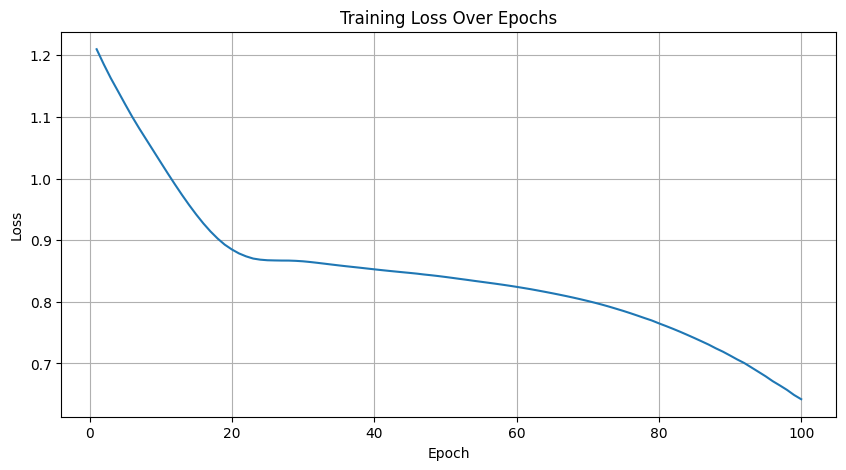

In [16]:

# ====================================================
# Step 11: Plot Training Loss
# ====================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Over Epochs")

plt.grid(True)

plt.show()



## 💾 Step 12: Save the Trained Model


In [17]:

# ====================================================
# Step 12: Save the Model
# ====================================================

torch.save(
    model.state_dict(),
    "nyc_housing_price_model.pth"
)

print("Model saved successfully!")


Model saved successfully!
